# 01. 1차원 천수방정식과 중력파

이 노트북에서는 가장 단순한 해양 **전진모델(forward model)** — 1차원 선형
천수방정식(shallow water equations, SWE) — 을 격자 위에서 직접 적분한다.

$$
\frac{\partial u}{\partial t} = -g\,\frac{\partial \eta}{\partial x},
\qquad
\frac{\partial \eta}{\partial t} = -H\,\frac{\partial u}{\partial x}
$$

여기서 $u$ 는 유속, $\eta$ 는 자유표면 변위, $H$ 는 평균 수심, $g$ 는 중력가속도다.
두 식을 합치면 파동방정식 $\partial_{tt}\eta = gH\,\partial_{xx}\eta$ 가 되어,
속도 $c=\sqrt{gH}$ 의 **중력파(gravity wave)** 가 양방향으로 전파한다.

학습 목표:

1. **엇갈린 격자(staggered grid)**: $\eta$ 와 $u$ 를 반 칸 어긋나게 두는 이유
2. **forward–backward** 시간적분 구현
3. 중력파 속도 $c=\sqrt{gH}$ 와 **CFL 조건** $c\,\Delta t/\Delta x \le 1$ 확인
4. 봉우리 분리·벽 반사 등 초기값 실험
5. **에너지 보존** 점검과 leapfrog 의 계산모드/안정성 비교

> 단위는 무차원으로 둔다($g=H=1\Rightarrow c=1$). 회전·차원 스케일은 Stage 3부터 도입한다.

## 1. 라이브러리 불러오기

`src/shallow_water/` 의 모듈을 재사용한다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_project_root(markers=("pyproject.toml", ".git")):
    # 노트북에는 __file__ 이 없으므로 cwd 에서 위로 올라가며 루트를 찾는다.
    start = Path.cwd().resolve()
    for path in (start, *start.parents):
        if any((path / m).exists() for m in markers):
            return path
    return start.parent if start.name == "notebooks" else start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

from shallow_water.grids.grid1d import StaggeredGrid1D
from shallow_water.dynamics import swe1d
from shallow_water.utils.io import get_output_dirs

OUT = get_output_dirs(PROJECT_ROOT)
FIG = OUT["figures"]
print("project root:", PROJECT_ROOT)
print("figures →", FIG)

project root: /Users/sanggyu/projects/shallow-water-lab
figures → /Users/sanggyu/projects/shallow-water-lab/outputs/figures


## 2. 엇갈린 격자 (staggered grid)

$\eta$ 와 $u$ 를 같은 점에 두면(collocated), 압력경도 $\partial\eta/\partial x$ 를
중앙차분할 때 바로 옆 칸이 빠져 **격자 잡음($2\Delta x$ 노이즈)** 이 생긴다.

대신 $\eta$ 는 셀 중심, $u$ 는 셀 face 에 **반 칸 어긋나게** 두면:

- 압력경도 $\partial\eta/\partial x$ 가 두 $\eta$ 사이의 face(=$u$ 위치)에서 인접차분 한 번으로,
- 발산 $\partial u/\partial x$ 가 두 $u$ 사이의 셀 중심(=$\eta$ 위치)에서 인접차분 한 번으로

깔끔히 계산된다. 이것이 1차원 staggered grid (2차원에서는 Arakawa C-grid)다.

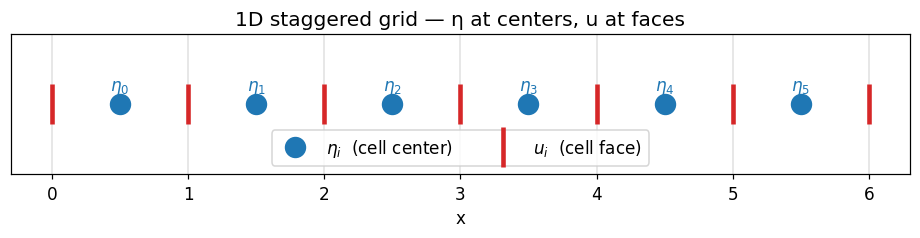

In [2]:
fig, ax = plt.subplots(figsize=(8.5, 2.3))
nx, dx = 6, 1.0
xeta = (np.arange(nx) + 0.5) * dx
xu = np.arange(nx + 1) * dx
for x in xu:
    ax.axvline(x, color="0.88", lw=1.0, zorder=0)
ax.plot(xeta, np.zeros_like(xeta), "o", color="C0", ms=13, label=r"$\eta_i$  (cell center)")
ax.plot(xu, np.zeros_like(xu), "|", color="C3", ms=26, mew=3, label=r"$u_{i}$  (cell face)")
for i, x in enumerate(xeta):
    ax.annotate(fr"$\eta_{i}$", (x, 0.05), ha="center", color="C0")
ax.set_yticks([]); ax.set_ylim(-0.25, 0.25)
ax.set_xlabel("x"); ax.set_title("1D staggered grid — η at centers, u at faces")
ax.legend(loc="lower center", ncol=2)
fig.tight_layout(); fig.savefig(FIG / "01_staggered_grid.png", bbox_inches="tight"); plt.show()

## 3. 격자·초기조건과 CFL

도메인 $[0, L]$ 을 균일 격자로 나누고 $g=H=1$ 로 둔다 ($c=\sqrt{gH}=1$).
시간간격은 CFL 수 $C=c\,\Delta t/\Delta x$ 로 정한다. $C\le 1$ 이 안정 조건이다.

초기조건은 정지 상태($u=0$)의 매끄러운 가우시안 봉우리로 둔다.

In [3]:
g, H = 1.0, 1.0
L, nx = 200.0, 400
grid = StaggeredGrid1D(nx=nx, Lx=L, periodic=True)
c = grid.gravity_wave_speed(g, H)
C = 0.5
dt = C * grid.dx / c
print(f"dx = {grid.dx}, c = {c}, dt = {dt}, CFL = {grid.cfl(g, H, dt):.2f}")


def gaussian(x, x0, w):
    return np.exp(-(((x - x0) / w) ** 2))


eta0 = gaussian(grid.x_eta, L / 2, 4.0)
u0 = np.zeros(grid.n_u)

dx = 0.5, c = 1.0, dt = 0.25, CFL = 0.50


## 4. 봉우리의 분리 — 양방향 중력파

정지 상태의 봉우리 $\eta(x,0)=F(x),\ u(x,0)=0$ 는 절반 크기의 두 파동으로 갈라져
각각 $+c,\ -c$ 로 진행한다 (D'Alembert 해). 시간이 지나면 봉우리는 둘로 나뉘어
양쪽으로 멀어진다.

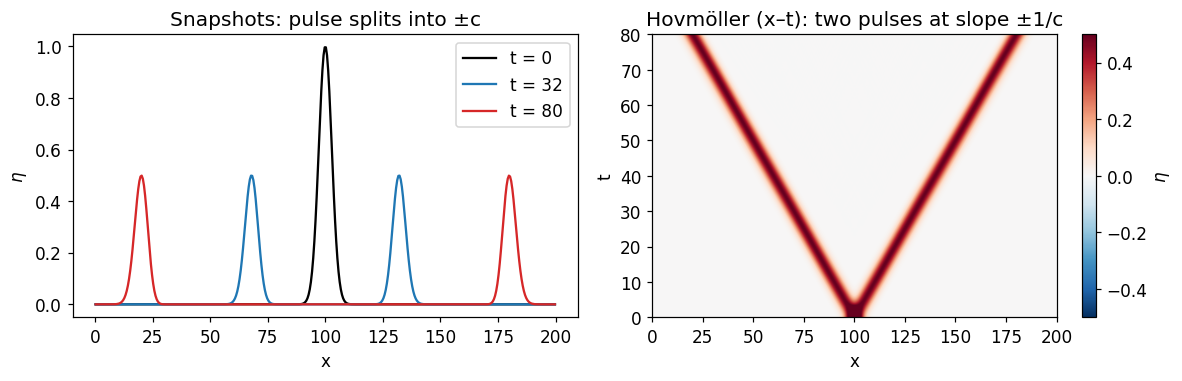

오른쪽 봉우리 위치: 179.8  (이론 L/2 + cT = 180.0)


In [4]:
T = 80.0
nsteps = int(round(T / dt))
res = swe1d.run(grid, eta0, u0, g, H, dt, nsteps=nsteps, save_every=max(1, nsteps // 200))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
for frac, col in zip([0.0, 0.4, 1.0], ["k", "C0", "C3"]):
    k = int(frac * (len(res["eta_hist"]) - 1))
    ax.plot(grid.x_eta, res["eta_hist"][k], col,
            label=f"t = {res['save_times'][k]:.0f}")
ax.set_xlabel("x"); ax.set_ylabel(r"$\eta$"); ax.legend()
ax.set_title("Snapshots: pulse splits into ±c")

ax = axes[1]
im = ax.imshow(res["eta_hist"], aspect="auto", origin="lower", cmap="RdBu_r",
               extent=[0, L, 0, res["save_times"][-1]], vmin=-0.5, vmax=0.5)
ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title("Hovmöller (x–t): two pulses at slope ±1/c")
fig.colorbar(im, ax=ax, label=r"$\eta$")
fig.tight_layout(); fig.savefig(FIG / "01_pulse_split.png", bbox_inches="tight"); plt.show()

# 분리된 봉우리 위치로 파속 확인
eta_T = res["eta"]
right = grid.x_eta > L / 2
x_peak = grid.x_eta[right][np.argmax(eta_T[right])]
print(f"오른쪽 봉우리 위치: {x_peak:.1f}  (이론 L/2 + cT = {L/2 + c*T:.1f})")

## 5. 단방향 파동과 벽 반사

오른쪽으로만 가는 파동은 $u=\sqrt{g/H}\,\eta$ 로 초기화하면 만들어진다
(linear SWE 의 Riemann 불변량). 양 끝을 **벽**($u=0$)으로 두면 파동은 벽에서
부호를 유지한 채 반사된다.

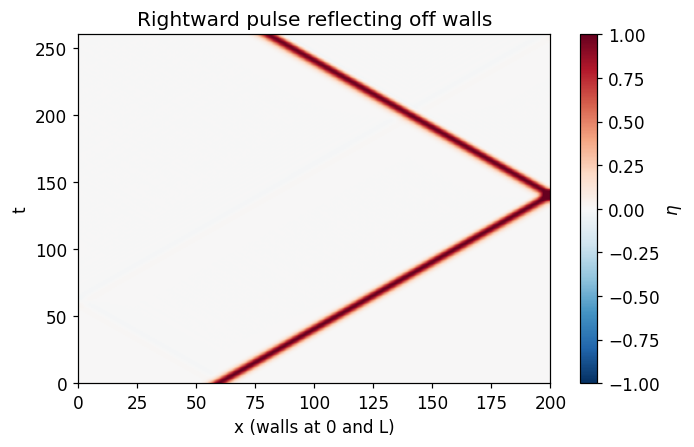

In [5]:
gw = StaggeredGrid1D(nx=nx, Lx=L, periodic=False)
dtw = 0.5 * gw.dx / c
eta0w = gaussian(gw.x_eta, L * 0.3, 4.0)
u0w = np.zeros(gw.n_u)
# eta 를 내부 face 로 보간해 오른쪽 진행파 구성
eta_face = 0.5 * (eta0w[:-1] + eta0w[1:])
u0w[1:-1] = np.sqrt(g / H) * eta_face

Tw = 260.0
nstepsw = int(round(Tw / dtw))
resw = swe1d.run(gw, eta0w, u0w, g, H, dtw, nsteps=nstepsw,
                 save_every=max(1, nstepsw // 240))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
im = ax.imshow(resw["eta_hist"], aspect="auto", origin="lower", cmap="RdBu_r",
               extent=[0, L, 0, resw["save_times"][-1]], vmin=-1, vmax=1)
ax.set_xlabel("x (walls at 0 and L)"); ax.set_ylabel("t")
ax.set_title("Rightward pulse reflecting off walls")
fig.colorbar(im, ax=ax, label=r"$\eta$")
fig.tight_layout(); fig.savefig(FIG / "01_wall_reflection.png", bbox_inches="tight"); plt.show()

## 6. CFL 안정조건

명시적 스킴은 한 스텝에 정보가 한 칸 이상 건너뛰면 안 된다.
중력파의 CFL 조건은

$$
C = \frac{c\,\Delta t}{\Delta x} \le 1.
$$

$C\le 1$ 이면 안정, $C>1$ 이면 격자규모 진동이 폭발적으로 증폭한다.

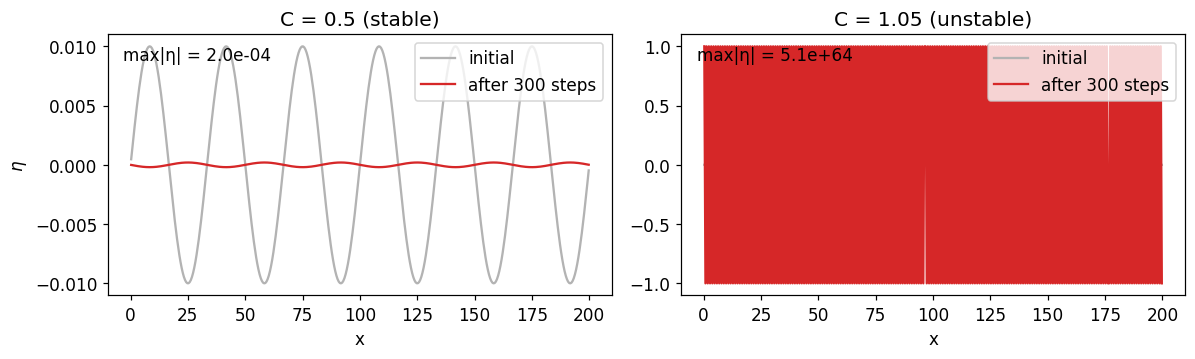

In [6]:
eta_sine = 0.01 * np.sin(2 * np.pi * 6 * grid.x_eta / L)
u_sine = np.zeros(grid.n_u)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=False)
for ax, Cfl, title in zip(axes, [0.5, 1.05], ["C = 0.5 (stable)", "C = 1.05 (unstable)"]):
    dtc = Cfl * grid.dx / c
    with np.errstate(over="ignore", invalid="ignore"):
        rc = swe1d.run(grid, eta_sine, u_sine, g, H, dtc, nsteps=300)
    ax.plot(grid.x_eta, eta_sine, "0.7", label="initial")
    ax.plot(grid.x_eta, np.clip(rc["eta"], -1, 1), "C3", label="after 300 steps")
    ax.set_title(title); ax.set_xlabel("x"); ax.legend()
    mx = np.nanmax(np.abs(rc["eta"]))
    ax.text(0.03, 0.9, f"max|η| = {mx:.1e}", transform=ax.transAxes)
axes[0].set_ylabel(r"$\eta$")
fig.tight_layout(); fig.savefig(FIG / "01_cfl_stability.png", bbox_inches="tight"); plt.show()

## 7. 에너지 보존과 시간적분 스킴

선형 천수계의 총 에너지는

$$
E = \underbrace{\tfrac12 H\!\int u^2\,dx}_{\text{운동}} +
    \underbrace{\tfrac12 g\!\int \eta^2\,dx}_{\text{위치}}
$$

이며 보존되어야 한다. **forward–backward(FB)** 는 단일 시간층으로 에너지를
거의 완벽히 보존한다. 반면 **leapfrog** 은 2차 정확하지만

- 엇갈린 격자에서 격자규모 모드 때문에 안정한계가 $C\le 0.5$ 로 더 빡빡하고,
- 짝/홀 시간층이 갈라지는 **계산모드(computational mode)** 가 있어
  Robert–Asselin 시간필터로 억제해야 한다.

아래에서 (1) FB 의 에너지 보존, (2) FB($C=0.5,0.95$)·leapfrog($C=0.5$ 폭주,
$C=0.4$+필터 안정)의 안정성을 비교한다.

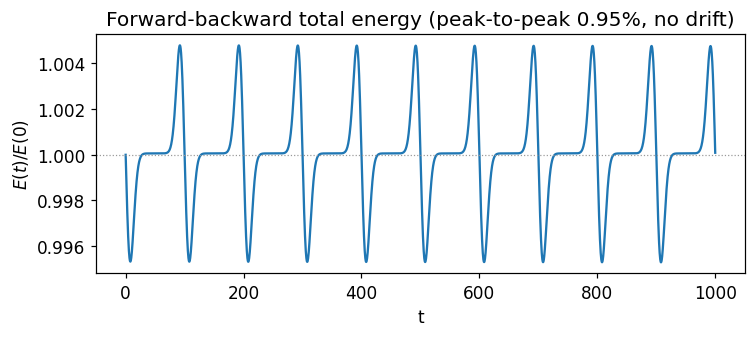

상대 에너지 변동(peak-to-peak): 0.951%  — 시간이 지나도 커지지 않는다(보존)


In [7]:
# 매끄러운(넓은) 봉우리일수록 FB 의 에너지 변동이 작다.
eta_smooth = gaussian(grid.x_eta, L / 2, 16.0)
res_fb = swe1d.run(grid, eta_smooth, u0, g, H, 0.5 * grid.dx / c, nsteps=4000)
E = res_fb["energy"]
span = (E.max() - E.min()) / E[0] * 100
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(res_fb["times"], E / E[0], "C0")
ax.axhline(1.0, color="0.6", lw=0.8, ls=":")
ax.set_xlabel("t"); ax.set_ylabel(r"$E(t)/E(0)$")
ax.set_title(f"Forward-backward total energy (peak-to-peak {span:.2f}%, no drift)")
fig.tight_layout(); fig.savefig(FIG / "01_energy.png", bbox_inches="tight"); plt.show()
print(f"상대 에너지 변동(peak-to-peak): {span:.3f}%  — 시간이 지나도 커지지 않는다(보존)")

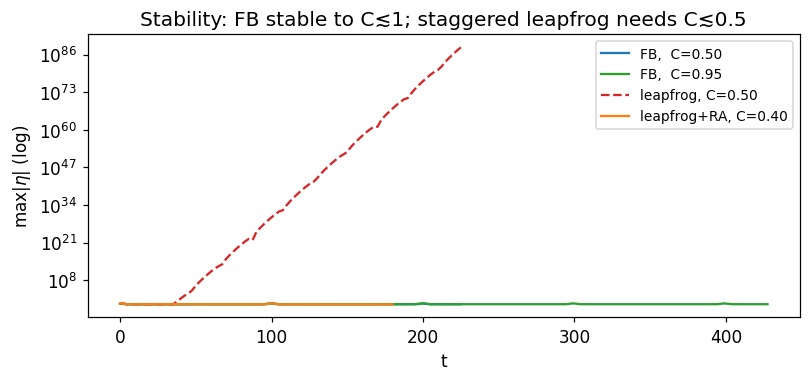

In [8]:
def max_amp_series(scheme, Cfl, ra_nu=0.05, nsteps=900):
    dtc = Cfl * grid.dx / c
    with np.errstate(over="ignore", invalid="ignore"):
        r = swe1d.run(grid, eta0, u0, g, H, dtc, nsteps=nsteps,
                      scheme=scheme, ra_nu=ra_nu, save_every=10)
    amp = np.array([np.nanmax(np.abs(h)) for h in r["eta_hist"]])
    return r["save_times"], amp

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for label, (scheme, Cfl, nu, style) in {
    "FB,  C=0.50":      ("forward_backward", 0.50, 0.0, "C0-"),
    "FB,  C=0.95":      ("forward_backward", 0.95, 0.0, "C2-"),
    "leapfrog, C=0.50": ("leapfrog", 0.50, 0.05, "C3--"),
    "leapfrog+RA, C=0.40": ("leapfrog", 0.40, 0.05, "C1-"),
}.items():
    t, amp = max_amp_series(scheme, Cfl, nu)
    ax.semilogy(t, amp, style, label=label)
ax.set_xlabel("t"); ax.set_ylabel(r"max$|\eta|$ (log)")
ax.set_title("Stability: FB stable to C≲1; staggered leapfrog needs C≲0.5")
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(FIG / "01_stability_schemes.png", bbox_inches="tight"); plt.show()

## 8. 정리

- $\eta$(중심)·$u$(face)의 **엇갈린 격자**로 압력경도와 발산을 잡음 없이 계산했다.
- **forward–backward** 로 적분해 봉우리가 $\pm c$ 로 갈라지고 벽에서 반사되는
  중력파를 재현하고, **CFL** $C\le1$ 안정조건을 확인했다.
- FB 는 에너지를 매우 잘 보존하며, leapfrog 은 엇갈린 격자에서 $C\le 0.5$ 한계와
  계산모드(→ Robert–Asselin 필터)를 가진다.

다음(Stage 2)에서는 이 구조를 2차원 **Arakawa C-grid** 로 확장해 중력파의
2차원 전파와 경계 반사를 다룬다.